# 🧍 Daily Standup Bot - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/standup-bot/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/standup-bot/demo.ipynb)

> *"Standup notes are scattered across Slack."*

Each person submits three fields - **yesterday / today / blockers** - and the bot rolls
the day into one clean digest, with **blockers surfaced at the top** so nothing slips.

**What we cover**
1. Collect updates
2. Detect real blockers
3. Build the daily digest
4. Where Claude adds a narrative summary
5. Visualize team focus & blockers


## Step 1 - Collect the updates

A tiny store, one update per person per day (re-submitting replaces).


In [1]:
from __future__ import annotations
from collections import defaultdict
from dataclasses import dataclass, field
from datetime import date
from typing import Dict, List, Optional

@dataclass
class Update:
    name: str; yesterday: str=""; today: str=""; blockers: str=""
    @property
    def has_blocker(self):
        b = self.blockers.strip().lower()
        return bool(b) and b not in {"none","no","n/a","-","nothing"}

@dataclass
class StandupStore:
    by_date: Dict[str, List[Update]] = field(default_factory=lambda: defaultdict(list))
    def submit(self, u: Update, day=None):
        day = day or date.today().isoformat()
        for i, e in enumerate(self.by_date[day]):
            if e.name.strip().lower() == u.name.strip().lower():
                self.by_date[day][i] = u; return
        self.by_date[day].append(u)
    def get(self, day=None):
        return list(self.by_date.get(day or date.today().isoformat(), []))

DAY = "2026-06-21"
s = StandupStore()
s.submit(Update("Ana","shipped CSV loader","review PRs","none"), DAY)
s.submit(Update("Sam","trained churn model","tune hyperparams","waiting on GPU quota"), DAY)
s.submit(Update("Ria","built RAG demo","ship LLM endpoint","blocked: missing API key"), DAY)
s.submit(Update("Lee","fixed pipeline retries","backfill data","none"), DAY)
print(len(s.get(DAY)), "updates collected")

4 updates collected


## Step 2 - Detect real blockers

"none" / "n/a" / "-" don't count. Only genuine blockers get escalated.


In [2]:
for u in s.get(DAY):
    print(f"{u.name:5s} blocker? {u.has_blocker}  ({u.blockers!r})")

Ana   blocker? False  ('none')
Sam   blocker? True  ('waiting on GPU quota')
Ria   blocker? True  ('blocked: missing API key')
Lee   blocker? False  ('none')


## Step 3 - Build the digest

Deterministic Markdown, blockers first. No API needed.


In [3]:
def build_digest(updates, day):
    if not updates:
        return f"# Daily Standup - {day}\n\n_No updates yet._\n"
    blocked = [u for u in updates if u.has_blocker]
    L = [f"# Daily Standup - {day}", "", f"**{len(updates)} update(s)** · **{len(blocked)} blocker(s)**", ""]
    if blocked:
        L.append("## 🚧 Blockers (action needed)")
        L += [f"- **{u.name}**: {u.blockers.strip()}" for u in blocked]
        L.append("")
    L.append("## Updates")
    for u in updates:
        L.append(f"### {u.name}")
        if u.yesterday.strip(): L.append(f"- *Yesterday:* {u.yesterday.strip()}")
        if u.today.strip(): L.append(f"- *Today:* {u.today.strip()}")
        L.append(f"- *Blockers:* {u.blockers.strip() if u.has_blocker else 'none'}")
        L.append("")
    return "\n".join(L).rstrip()+"\n"

from IPython.display import Markdown
Markdown(build_digest(s.get(DAY), DAY))

# Daily Standup - 2026-06-21

**4 update(s)** · **2 blocker(s)**

## 🚧 Blockers (action needed)
- **Sam**: waiting on GPU quota
- **Ria**: blocked: missing API key

## Updates
### Ana
- *Yesterday:* shipped CSV loader
- *Today:* review PRs
- *Blockers:* none

### Sam
- *Yesterday:* trained churn model
- *Today:* tune hyperparams
- *Blockers:* waiting on GPU quota

### Ria
- *Yesterday:* built RAG demo
- *Today:* ship LLM endpoint
- *Blockers:* blocked: missing API key

### Lee
- *Yesterday:* fixed pipeline retries
- *Today:* backfill data
- *Blockers:* none


## Step 4 - Where Claude adds value

With `ANTHROPIC_API_KEY` set, the bot can replace the template with a narrative summary -
a one-line team status, ranked blockers, and themes. The contract is identical, so the
template is a safe offline fallback.

```python
from anthropic import Anthropic
client = Anthropic(api_key=key)
msg = client.messages.create(model="claude-opus-4-8", max_tokens=800,
    messages=[{"role":"user","content": build_prompt(updates, day)}])
digest = msg.content[0].text
```


## Step 5 - Team focus & blockers, visualized

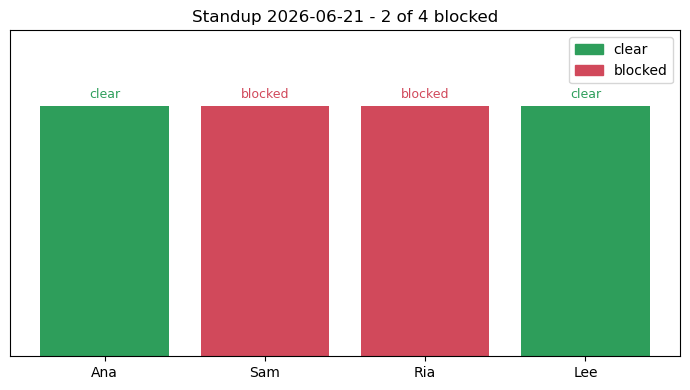

In [4]:
import matplotlib.pyplot as plt

ups = s.get(DAY)
names = [u.name for u in ups]
blocked = [1 if u.has_blocker else 0 for u in ups]
colors = ["#d1495b" if b else "#2e9e5b" for b in blocked]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, [1]*len(names), color=colors)
ax.set_yticks([]); ax.set_ylim(0,1.3)
for i,u in enumerate(ups):
    ax.text(i, 1.03, "blocked" if u.has_blocker else "clear", ha="center", fontsize=9,
            color="#d1495b" if u.has_blocker else "#2e9e5b")
ax.set_title(f"Standup {DAY} - {sum(blocked)} of {len(ups)} blocked")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2e9e5b",label="clear"),Patch(color="#d1495b",label="blocked")])
plt.tight_layout(); plt.savefig("standup.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- One store collects **yesterday / today / blockers** per person (dedup by name).
- `has_blocker` filters out "none"/"n/a" so only real blockers escalate.
- `build_digest` produces a clean Markdown standup, **blockers first** - and Claude can
  upgrade it to a narrative summary when a key is present.

This is the engine behind the FastAPI service in `api.py`.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run the service:**
```bash
pip install -r requirements.txt
uvicorn api:app --reload
# open http://localhost:8000 - submit updates, refresh the digest
# set ANTHROPIC_API_KEY and call /digest?ai=true for the narrative version
```
